# 1. Business Question: 
This analysis examines manufacturing production performance across machines, shifts, and products to determine which factors are associated with differences in output, production target achievement, and quality. The analysis also investigates whether apparent differences in production persist after accounting for differences in production targets. Using exploratory data analysis, statistical testing, and regression modeling, the goal is to distinguish meaningful operational differences from variation that can be explained by production expectations and to identify findings that could support manufacturing performance improvement.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


from scipy.stats import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import pingouin as pg # For Welch's ANOVA 
from scipy.stats import levene

df = pd.read_excel(r"C:\Users\Admin\OneDrive\Desktop\manufacturing-operations-analysis\data\manufacturing_operations_data.xlsx")

df.info(),  df.shape, df.describe(), df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7602 entries, 0 to 7601
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Record_ID       7602 non-null   int64         
 1   Date            7602 non-null   datetime64[ns]
 2   Plant           7602 non-null   object        
 3   Machine         7602 non-null   object        
 4   Shift           7602 non-null   object        
 5   Product         7602 non-null   object        
 6   Target_Units    7602 non-null   int64         
 7   Produced_Units  7602 non-null   int64         
 8   Good_Units      7602 non-null   int64         
 9   Defects         7602 non-null   int64         
 10  Downtime_Hours  7602 non-null   float64       
 11  Downtime_Cause  4450 non-null   object        
 12  Labor_Hours     7602 non-null   float64       
 13  Material_Cost   7602 non-null   float64       
 14  Labor_Cost      7602 non-null   float64       
 15  Down

(None,
 (7602, 20),
          Record_ID                 Date  Target_Units  Produced_Units  \
 count  7602.000000                 7602   7602.000000     7602.000000   
 mean   3801.500000  2026-04-01 00:00:00    345.947777      314.475533   
 min       1.000000  2026-01-01 00:00:00    150.000000       98.000000   
 25%    1901.250000  2026-02-15 00:00:00    255.250000      236.000000   
 50%    3801.500000  2026-04-01 00:00:00    363.000000      325.000000   
 75%    5701.750000  2026-05-16 00:00:00    419.000000      382.000000   
 max    7602.000000  2026-06-30 00:00:00    621.000000      626.000000   
 std    2194.652706                  NaN     96.414960       92.319073   
 
         Good_Units      Defects  Downtime_Hours  Labor_Hours  Material_Cost  \
 count  7602.000000  7602.000000     7602.000000  7602.000000    7602.000000   
 mean    306.176796     8.298737        1.461247     7.499198     840.146030   
 min      98.000000     0.000000        0.000000     6.500000     261.37

In [2]:
# Change columns to categorical
categorical_columns = [
    "Plant",
    "Machine",
    "Shift",
    "Product",
    "Downtime_Cause"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")


In [3]:
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Plant ---
Plant
Plant A    3801
Plant B    3801
Name: count, dtype: int64

--- Machine ---
Machine
ASSEMBLY-301    1086
ASSEMBLY-302    1086
CNC-101         1086
CNC-102         1086
CNC-103         1086
PRESS-201       1086
PRESS-202       1086
Name: count, dtype: int64

--- Shift ---
Shift
1st    2534
2nd    2534
3rd    2534
Name: count, dtype: int64

--- Product ---
Product
Component X    2309
Component Y    2131
Component Z    1780
Component W    1382
Name: count, dtype: int64

--- Downtime_Cause ---
Downtime_Cause
Mechanical             1418
Changeover             1040
Material Shortage       815
Planned Maintenance     654
Quality Hold            523
Name: count, dtype: int64


# 2. Data Overview
The synthetic dataset contains 7,602 production records across seven machines, three shifts, four products, and five causes for downtime.

# 3. KPI/Feature Engineering

Achievement Rate measures actual production relative to the established production target. An Achievement Rate of 1.00 indicates that production met the target, while values below 1.00 indicate that production fell short of the target and values above 1.00 indicate that production exceeded the target. This metric provides a normalized measure of production performance that allows comparisons across observations with different production targets.

Quality Rate measures the proportion of produced units that meet quality requirements. A higher Quality Rate indicates that a greater proportion of production met quality standards. This metric complements production volume and Achievement Rate by evaluating whether output was produced successfully rather than simply measuring how many units were produced.

In [4]:
df["Achievement"] = (
    df["Produced_Units"] / df["Target_Units"]
)
df["Quality_Rate"] = (
    df["Good_Units"] / df["Produced_Units"]
)

# 4. Exploratory Analysis


4.1. Production by Machine

4.2. Production by Shift

4.3. Target vs Produced scatterplot

4.4. Achievement Rate by Shift 

4.5. Quality Rate Shift


## 4.1. Production by Machine

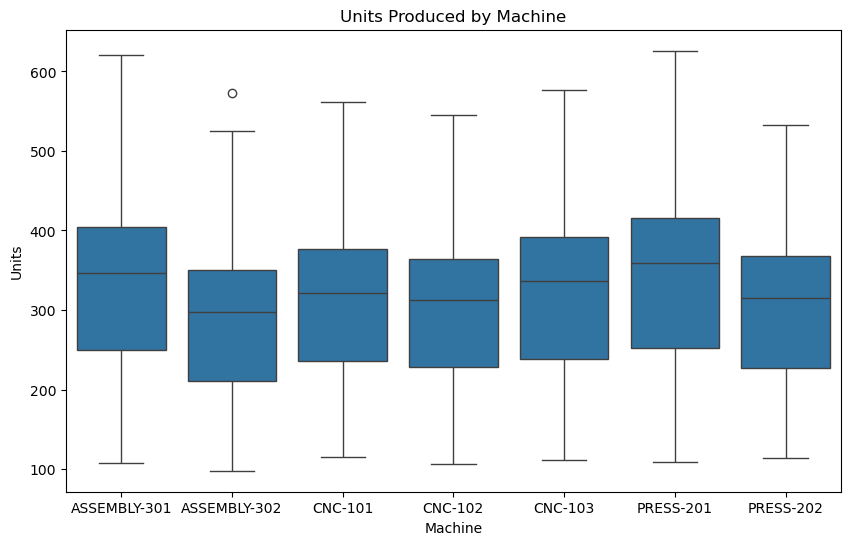

In [5]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Machine",
    y="Produced_Units"
)

plt.title("Units Produced by Machine")
plt.ylabel("Units")
plt.xlabel("Machine")
plt.show()

Average production varies across machines, with PRESS-201 and ASSEMBLY-301 showing the highest average output and ASSEMBLY-302 showing the lowest. These differences motivate the subsequent statistical testing of machine-level production differences.

## 4.2. Production by Shift

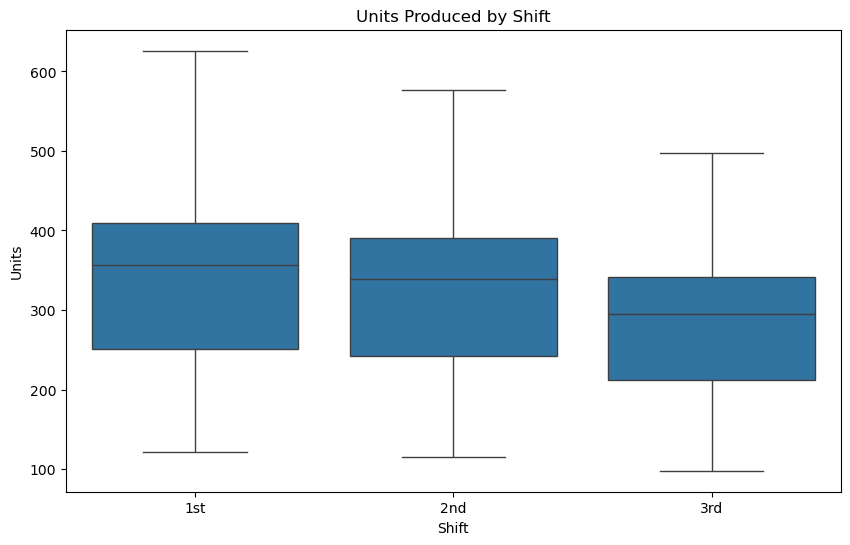

In [6]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Shift",
    y="Produced_Units"
)

plt.title("Units Produced by Shift")
plt.ylabel("Units")
plt.xlabel("Shift")
plt.show()

Average production decreases across shifts, with 1st shift producing the highest average output and 3rd shift the lowest. This apparent difference warrants further investigation to determine whether it represents a meaningful operational effect or reflects differences in production targets.

## 4.3. Production Target vs. Actual Production

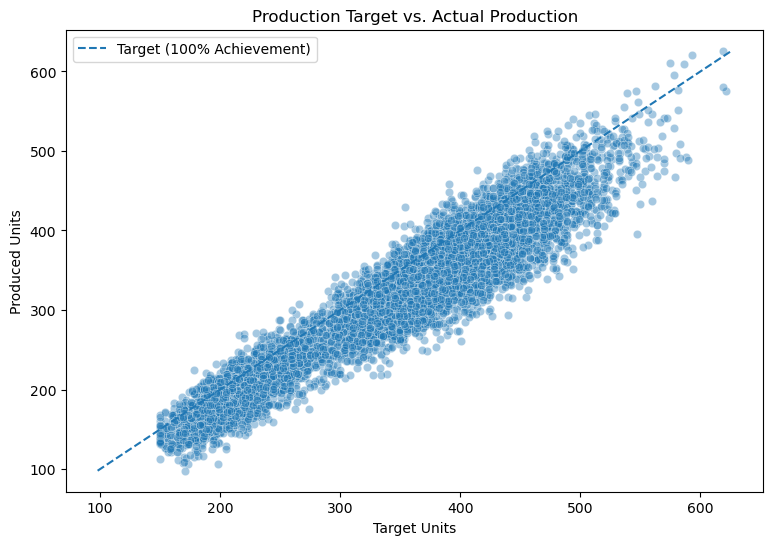

In [7]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Target_Units",
    y="Produced_Units",
    alpha=0.4
)

# Reference line: Produced Units = Target Units
min_value = min(df["Target_Units"].min(), df["Produced_Units"].min())
max_value = max(df["Target_Units"].max(), df["Produced_Units"].max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Target (100% Achievement)"
)

plt.title("Production Target vs. Actual Production")
plt.xlabel("Target Units")
plt.ylabel("Produced Units")
plt.legend()

plt.show()

Actual production shows a strong positive relationship with the assigned production target. This relationship suggests that differences in absolute production may partly reflect differences in expected production levels, motivating analysis of Achievement Rate as a normalized performance measure.

## 4.4. Achievement Rate by Shift

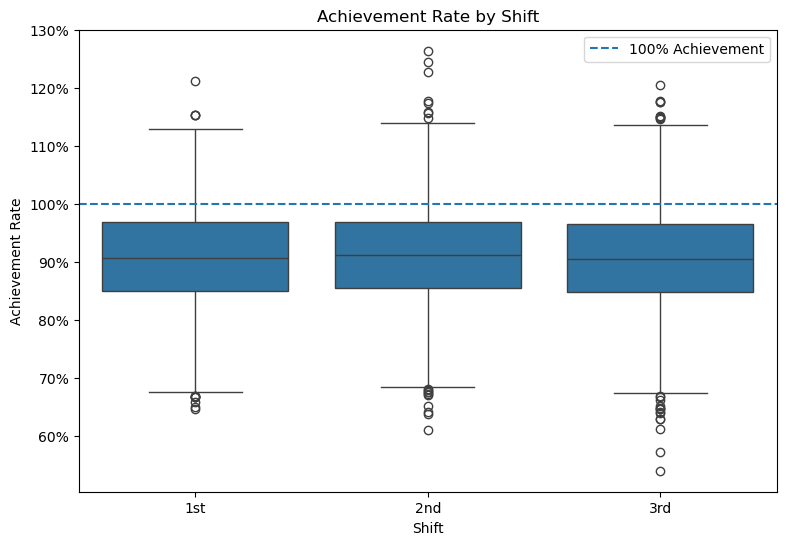

In [8]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Shift",
    y="Achievement"
)

plt.axhline(
    1.0,
    linestyle="--",
    label="100% Achievement"
)

plt.title("Achievement Rate by Shift")
plt.xlabel("Shift")
plt.ylabel("Achievement Rate")

plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

plt.legend()

plt.show()

Despite substantial differences in absolute production across shifts, Achievement Rate distributions are similar and show considerable overlap.

## 4.5. Quality Rate by Shift

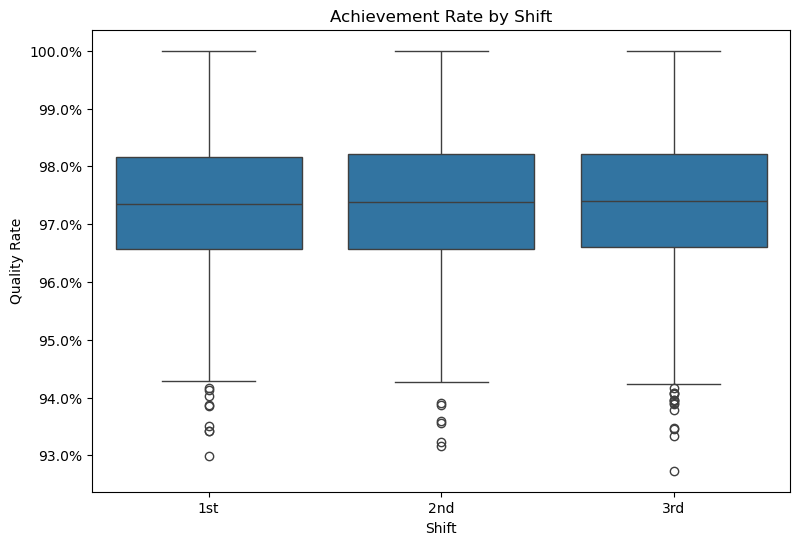

In [9]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Shift",
    y="Quality_Rate"
)


plt.title("Achievement Rate by Shift")
plt.xlabel("Shift")
plt.ylabel("Quality Rate")

plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

plt.show()

Quality rates appear relatively similar across  shifts despite substantial differences in absolute production. This suggests that production volume and performance relative to target may tell different stories.

# 5. Statistical Analysis


Question 1: Does absolute production differ by machine, shift, or product?

Question 2: Are the differences still present after accounting for production targets?

Question 3: Does achievement differ across machines, shifts, or products?

Question 4: Does quality differ?

In [10]:
## Check variance assumption
levene_machine = levene(
    *[group["Produced_Units"].values for _, group in df.groupby("Machine", observed = True)]
)

levene_shift = levene(
    *[group["Produced_Units"].values for _, group in df.groupby("Shift", observed = True)]
)

## Question 5.1: Does absolute production differ by machine, shift, or product?
Levene's tests indicated that the equal-variance assumption was violated for both machine and shift with p < 0.001. Therefore, Welch's ANOVA was used instead of the standard ANOVA, with Games-Howell post-hoc comparisons for significant effects.


In [11]:
welch_machine = pg.welch_anova(
    data=df,
    dv="Produced_Units",
    between="Machine"
)

welch_shift = pg.welch_anova(
    data=df,
    dv="Produced_Units",
    between="Shift"
)

welch_product = pg.welch_anova(
    data=df,
    dv="Produced_Units",
    between="Product"
)

results_51 = pd.DataFrame({
    "Factor": ["Machine", "Shift", "Product"],
    "Welch F": [
        welch_machine.loc[0, "F"],
        welch_shift.loc[0, "F"],
        welch_product.loc[0, "F"]
    ],
    "p-value": [
        welch_machine.loc[0, "p-unc"],
        welch_shift.loc[0, "p-unc"],
        welch_product.loc[0, "p-unc"]
    ],
    "Effect Size": [
        welch_machine.loc[0, "np2"],
        welch_shift.loc[0, "np2"],
        welch_product.loc[0, "np2"]
    ]
})

results_51 = results_51.round({
    "Welch F": 2,
    "p-value": 4,
    "Effect Size": 3
})

results_51

,Factor,Welch F,p-value,Effect Size
0,Machine,49.56,0.0000,0.038
1,Shift,287.99,0.0000,0.065
2,Product,0.82,0.4826,0.000


Welch's ANOVA indicated statistically significant differences in absolute production across machines and shifts, while there is no indication of statistically significant differences in absolute production across product.

### Post-hoc Comparisons


In [12]:
games_howell_machine = pg.pairwise_gameshowell(
    data=df,
    dv="Produced_Units",
    between="Machine"
)

games_howell_shift = pg.pairwise_gameshowell(
    data=df,
    dv="Produced_Units",
    between="Shift"
)

machine_sig = games_howell_machine[
    games_howell_machine["pval"] < 0.05
][["A", "B", "diff", "pval", "hedges"]]

shift_sig = games_howell_shift[
    games_howell_shift["pval"] < 0.05
][["A", "B", "diff", "pval", "hedges"]]


In [13]:
machine_sig, shift_sig

(               A             B       diff          pval    hedges
 0   ASSEMBLY-301  ASSEMBLY-302  44.277164  0.000000e+00  0.494931
 1   ASSEMBLY-301       CNC-101  20.936464  2.694965e-06  0.227252
 2   ASSEMBLY-301       CNC-102  33.175875  0.000000e+00  0.363997
 5   ASSEMBLY-301     PRESS-202  27.511050  6.680279e-11  0.300774
 6   ASSEMBLY-302       CNC-101 -23.340700  6.475068e-09 -0.271297
 7   ASSEMBLY-302       CNC-102 -11.101289  3.795046e-02 -0.130638
 8   ASSEMBLY-302       CNC-103 -34.988029  1.013967e-12 -0.395581
 9   ASSEMBLY-302     PRESS-201 -55.558011  0.000000e+00 -0.609905
 10  ASSEMBLY-302     PRESS-202 -16.766114  9.993658e-05 -0.196497
 11       CNC-101       CNC-102  12.239411  2.004246e-02  0.139431
 12       CNC-101       CNC-103 -11.647330  4.615283e-02 -0.127790
 13       CNC-101     PRESS-201 -32.217311  0.000000e+00 -0.343783
 15       CNC-102       CNC-103 -23.886740  1.636192e-08 -0.264973
 16       CNC-102     PRESS-201 -44.456722  1.203815e-12 -0.47

### Question 5.1 Conclusion: 
Games-Howell post-hoc comparisons found significant differences among most machine pairs. The largest difference was between PRESS-201 and ASSEMBLY-302, with PRESS-201 producing approximately 55.6 more units on average. All three shifts differed significantly, with 1st shift producing the most and 3rd shift the least.

## Question 5.2: Are the differences still present after accounting for production targets?

In [14]:
target_production_corr = df[
    ["Target_Units", "Produced_Units"]
].corr()

target_production_corr

,Target_Units,Produced_Units
Target_Units,1.00000,0.94886
Produced_Units,0.94886,1.00000


In [15]:
target_adjusted_model = ols(
    "Produced_Units ~ Target_Units + C(Machine) + C(Shift) + C(Product)",
    data=df
).fit()

target_adjusted_anova = sm.stats.anova_lm(
    target_adjusted_model,
    typ=2
)

question_2_results = target_adjusted_anova[
    ["F", "PR(>F)"]
].copy()

question_2_results = question_2_results.rename(
    columns={
        "F": "F-statistic",
        "PR(>F)": "p-value"
    }
)

question_2_results = question_2_results.drop(
    index="Residual"
)

question_2_results

,F-statistic,p-value
C(Machine),0.513540,0.798559
C(Shift),1.531730,0.216228
C(Product),0.581900,0.626841
Target_Units,60707.486492,0.000000


### Question 5.2 Conclusion
After accounting for production targets, the differences in absolute production observed across machines, shifts, and products were no longer statistically significant. Machine (F = 0.514, p = .799), Shift (F = 1.532, p = .216), and Product (F = 0.582, p = .627) were not significant predictors of Produced Units. In contrast, Target Units was highly significant (F = 60,707.49, p < .001).

These results indicate that the differences in absolute production identified earlier are largely explained by differences in production targets. Once the expected production level is taken into account, there is insufficient evidence that machine, shift, or product independently affects production output.

## Question 5.3: Does achievement differ across machines, shifts, or products?

Achievement Rate measures production relative to the assigned production target, allowing performance to be compared across observations with different target levels. One-way ANOVA was used to test whether mean Achievement Rate differed across machines, shifts, or products.

In [16]:
achievement_model = ols(
    "Achievement ~ C(Machine) + C(Shift) + C(Product)",
    data=df
).fit()

achievement_anova = sm.stats.anova_lm(
    achievement_model,
    typ=2
)

achievement_results = achievement_anova.drop(index="Residual")[["F", "PR(>F)"]].copy()

achievement_results = achievement_results.rename(
    columns={
        "F": "F-statistic",
        "PR(>F)": "p-value"
    }
)

achievement_results.round(3)

,F-statistic,p-value
C(Machine),0.499,0.810
C(Shift),1.743,0.175
C(Product),0.572,0.633


### Question 5.3 Conclusion

No statistically significant differences in Achievement Rate were detected across machines (F = 0.499, p = .810), shifts (F = 1.743, p = .175), or products (F = 0.572, p = .633). These results indicate that production relative to the assigned target was consistent across the three factors.

Although absolute production differed substantially across machines and shifts, those differences did not translate into significant differences in Achievement Rate. This suggests that the production targets account for much of the observed variation in absolute output.

## Question 5.4: Does quality differ?

In [17]:
quality_model = ols(
    "Quality_Rate ~ C(Machine) + C(Shift) + C(Product)",
    data=df
).fit()

quality_anova = sm.stats.anova_lm(
    quality_model,
    typ=2
).drop(index="Residual")

quality_results = quality_anova[["F", "PR(>F)"]].copy()

quality_results.columns = ["F-statistic", "p-value"]

quality_results.round(3)

,F-statistic,p-value
C(Machine),2.489,0.021
C(Shift),0.729,0.482
C(Product),1.747,0.155


### Post-hot test on Machines

In [18]:
quality_games_howell = pg.pairwise_gameshowell(
    data=df,
    dv="Quality_Rate",
    between="Machine"
)

quality_games_howell

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,ASSEMBLY-301,ASSEMBLY-302,0.973550,0.974453,-0.000903,0.000511,-1.768119,2165.784133,0.569894,-0.075851
1,ASSEMBLY-301,CNC-101,0.973550,0.972644,0.000906,0.000518,1.748770,2169.386727,0.583072,0.075021
2,ASSEMBLY-301,CNC-102,0.973550,0.974145,-0.000595,0.000510,-1.167868,2164.834733,0.906153,-0.050101
3,ASSEMBLY-301,CNC-103,0.973550,0.973791,-0.000241,0.000522,-0.460749,2169.999900,0.999285,-0.019766
4,ASSEMBLY-301,PRESS-201,0.973550,0.973846,-0.000296,0.000516,-0.574032,2168.567788,0.997519,-0.024626
5,ASSEMBLY-301,PRESS-202,0.973550,0.973703,-0.000153,0.000511,-0.300389,2165.669645,0.999941,-0.012886
6,ASSEMBLY-302,CNC-101,0.974453,0.972644,0.001809,0.000507,3.571177,2168.380754,0.006667,0.153201
7,ASSEMBLY-302,CNC-102,0.974453,0.974145,0.000308,0.000498,0.618101,2169.951314,0.996258,0.026516
8,ASSEMBLY-302,CNC-103,0.974453,0.973791,0.000663,0.000511,1.297119,2165.743149,0.853487,0.055645
9,ASSEMBLY-302,PRESS-201,0.974453,0.973846,0.000608,0.000504,1.204819,2169.262226,0.892510,0.051686


### Question 5.4 Conclusion

Quality Rate differed significantly across machines (F = 2.489, p = .021), while no statistically significant differences were detected across shifts (F = 0.729, p = .482) or products (F = 1.747, p = .155). These results suggest that machine-level differences may be associated with quality performance, even though machine differences were not significant predictors of production after accounting for production targets.

Although the overall ANOVA detected a statistically significant difference in Quality Rate across machines (p = .021), Games-Howell comparisons identified only two significant pairwise differences: ASSEMBLY-302 versus CNC-101 (p = .0067) and CNC-101 versus CNC-102 (p = .0474). The corresponding effect sizes were very small (|Hedges' g| ≤ 0.153), and the largest difference in machine-level mean Quality Rate was less than 0.2 percentage points.

Therefore, the statistically significant machine effect appears to have limited practical significance. Overall quality performance was highly consistent across machines, with average Quality Rates clustered around 97–97.5%.

# 6. Assumptions
Levene's tests indicated unequal variances for both machine and shift (p < .001). Therefore, Welch's ANOVA and Games-Howell post-hoc comparisons were used to provide variance-robust inference. Residual diagnostics below indicate departures from normality; given the large sample size (n = 7,602), results were interpreted alongside robust methods rather than relying exclusively on classical ANOVA assumptions.

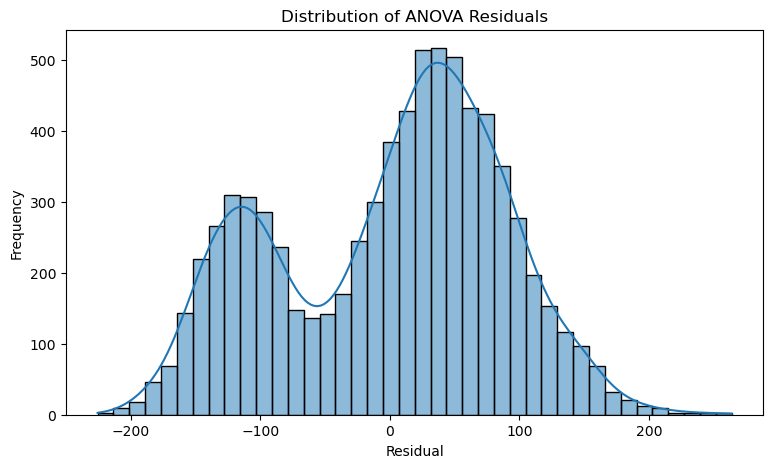

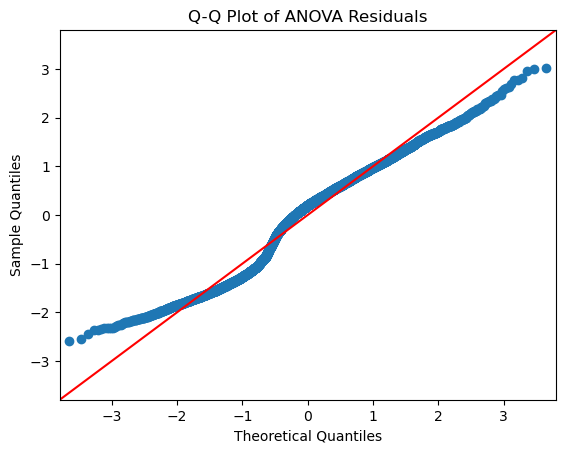

In [19]:
# Residual Normality - Make a histogram then a Q-Q-plot
additive_model = ols(
    "Produced_Units ~ C(Machine) + C(Shift)",
    data=df
).fit()

residuals = additive_model.resid

plt.figure(figsize=(9, 5))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.title("Distribution of ANOVA Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

fig = sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()

# 7. Final Findings


### 1. Absolute production differs by machine and shift.

Machine and shift were statistically significant predictors of absolute production.

### 2. Shift had the larger effect.

Shift explained approximately 6.5% of production variation compared with 3.8% for machine.

### 3. Production targets explain most of the variation in output.

Target Units was strongly correlated with Produced Units (r = 0.949), with a simple regression R² of approximately 0.90.

### 4. Apparent machine and shift effects disappear after controlling for target.

Machine, shift, and product were no longer statistically significant predictors after Target Units was included.

### 5. Production achievement tells a different story than raw production.

There was no significant evidence that machine, shift, or product affected achievement.